# Modèles de régression — comparaison sur un protocole commun

**Objectif.** Évaluer toutes les familles de modèles du projet avec **le même protocole** (mêmes cibles, mêmes plis, mêmes mesures), pour pouvoir les comparer directement. Chaque famille a sa section, remplie par la personne qui en est chargée ; la partie 8 explique comment brancher un modèle sur le protocole commun.

**Exécution.** Depuis la racine du projet, de haut en bas, après `data_preprocessing.ipynb`, qui produit `data/cleaned/cleaned.csv`. Les figures sont enregistrées dans `report/figures/`. Les calculs longs sont gardés en cache dans `cache_modeles/` (non versionné) : relancer le notebook ne recalcule que les modèles nouveaux ou modifiés, ou tout si les données changent. Supprimer ce dossier pour tout recalculer.

**Sommaire**
1. Protocole et outils communs
2. Les données : un sous-jeu par cible
3. Référence : la moyenne
4. Modèles linéaires — *Paul*
5. Réduction de dimension — *à attribuer*
6. Arbres et méthodes d'ensemble — *Salomé* : 6.1 Arbre de décision · 6.2 Bagging et forêt aléatoire
7. Apprentissage semi-supervisé — *à attribuer*
8. Ajouter un modèle
9. Comparaison de tous les modèles

# 1. Protocole et outils communs

Tous les modèles suivent le même protocole :
- **une cible à la fois**, avec `get_xy` (lignes où la cible est mesurée, mesures répétées fusionnées) ;
- **validation croisée groupée par article** (`GroupKFold`, 5 plis) : toutes les lignes d'un article sont dans le même pli, le score mesure la capacité à prédire les soudures d'une étude inconnue ;
- **préparation dans un `Pipeline`**, réapprise dans chaque pli (imputation par la médiane, indicateurs « valeur manquante », one-hot, standardisation). Les arbres et forêts la reçoivent **sans standardisation** : elle ne change pas leurs prédictions, et sans elle leurs seuils se lisent en unités physiques ;
- **hyperparamètres réglés par validation croisée imbriquée** : une boucle externe (5 plis par article) mesure la performance, une boucle interne (5 plis par article, sur la seule partie entraînement) choisit les réglages. Les articles du pli de test ne servent jamais au réglage ;
- **mesures sur les prédictions hors pli** (chaque ligne prédite une fois, par un modèle qui ne l'a pas vue) :
  - **RMSE** = √(moyenne des (y − ŷ)²), dans l'unité de la cible ;
  - **écart-type de la RMSE entre plis**, pour la stabilité ;
  - **MAE** = moyenne des |y − ŷ|, l'erreur « typique » ;
  - **R²** = 1 − Σ(y − ŷ)² / Σ(y − ȳ)² : 0 signifie pas mieux que la moyenne, un R² négatif pire que la moyenne.

In [1]:
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import Memory
from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, GroupKFold, KFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor, plot_tree

sys.path.insert(0, "preprocessing")
from ml_dataset import TARGETS, get_xy, load_cleaned, make_preprocessor

FIGURES = Path("report/figures")
FIGURES.mkdir(parents=True, exist_ok=True)
N_PLIS = 5
GRAINE = 0
NOMS = {"yield": "Limite d'élasticité (MPa)", "uts": "Résistance à la traction (MPa)",
        "elongation": "Allongement (%)", "roa": "Striction (%)", "charpy": "Énergie Charpy (J)"}
# Cache des calculs longs : un résultat est réutilisé si le modèle et les données sont identiques.
memoire = Memory("cache_modeles", verbose=0)

**Outils.** Pour ajouter un modèle, il suffit d'écrire une fonction qui reçoit X et renvoie le modèle non entraîné, puis d'appeler `ajouter` (partie 8).

| Outil | Rôle |
|---|---|
| `pipeline(X, estimateur, standardiser=True)` | préparation commune + estimateur (étape nommée `modele`) |
| `regle(modele, grille)` | réglage des hyperparamètres par validation croisée interne groupée par article ; les paramètres de la grille sont préfixés par `modele__` |
| `ajouter(nom, fabrique)` | évalue le modèle sur les 5 cibles et range ses résultats |
| `tableau_complet(noms)` | toutes les mesures, par cible et par modèle |
| `comparer(mesure, noms)` | une mesure (R², RMSE…) pour plusieurs modèles, une ligne par cible |
| `hyperparametres(nom)` | réglages choisis dans chaque pli externe |
| `diagnostic(noms)` | R² sur les données apprises, en découpage aléatoire et par article (biais, variance, changement de domaine) ; garde le modèle final dans `finaux` |
| `figure_predit_reel(nom, fichier)` | prédictions hors pli contre valeurs réelles |
| `plage(noms)` | plage des valeurs prédites, comparée à celle des valeurs réelles |

In [2]:
def pipeline(X, estimateur, standardiser=True):
    """Préparation commune (réapprise dans chaque pli) + estimateur, sous le nom « modele »."""
    prep = make_preprocessor(X)
    if not standardiser:
        prep = prep.set_params(num__scale="passthrough")
    return Pipeline([("prep", prep), ("modele", estimateur)])


def regle(modele, grille):
    """Hyperparamètres choisis par validation croisée interne groupée par article."""
    return GridSearchCV(modele, grille, cv=GroupKFold(n_splits=N_PLIS),
                        scoring="neg_mean_squared_error", n_jobs=-1)


def _ajuster(modele, X, y, groups):
    """Entraîne une copie du modèle ; pour un GridSearchCV, transmet les articles à la boucle
    interne. Renvoie le modèle entraîné et les hyperparamètres choisis."""
    m = clone(modele)
    if isinstance(m, GridSearchCV):
        m.fit(X, y, groups=groups)
        return m.best_estimator_, m.best_params_
    return m.fit(X, y), {}


@memoire.cache
def evaluer(modele, X, y, groups, n_plis=N_PLIS):
    """Prédictions hors pli (GroupKFold par article), mesures d'erreur et hyperparamètres
    choisis dans chaque pli."""
    cv = GroupKFold(n_splits=n_plis)
    pred = pd.Series(np.nan, index=y.index)
    rmse_plis, choix_plis = [], []
    for train, test in cv.split(X, y, groups):
        m, params = _ajuster(modele, X.iloc[train], y.iloc[train], groups.iloc[train])
        choix_plis.append(params)
        pred.iloc[test] = m.predict(X.iloc[test])
        rmse_plis.append(mean_squared_error(y.iloc[test], pred.iloc[test]) ** 0.5)
    mesures = {
        "RMSE": mean_squared_error(y, pred) ** 0.5,
        "RMSE écart-type entre plis": np.std(rmse_plis),
        "MAE": mean_absolute_error(y, pred),
        "R²": r2_score(y, pred),
    }
    return pred, mesures, choix_plis


@memoire.cache
def _diagnostiquer(modele, X, y, groups):
    """Modèle final (réglé par validation croisée par article, entraîné sur toutes les lignes),
    R² sur les données apprises et R² en découpage aléatoire avec les mêmes réglages."""
    final, _ = _ajuster(modele, X, y, groups)
    pred_aleatoire = cross_val_predict(clone(final), X, y,
                                       cv=KFold(N_PLIS, shuffle=True, random_state=GRAINE))
    return final, r2_score(y, final.predict(X)), r2_score(y, pred_aleatoire)


MODELES = {}                              # nom -> fonction X -> modèle non entraîné
resultats, predictions, choix = {}, {}, {}  # clés (cible, nom)
finaux = {}                               # modèles finaux, remplis par diagnostic


def ajouter(nom, fabrique):
    """Évalue le modèle sur les 5 cibles avec le protocole commun et range les résultats."""
    MODELES[nom] = fabrique
    for cible, (X, y, groups) in donnees.items():
        pred, mesures, choix_plis = evaluer(fabrique(X), X, y, groups)
        resultats[(cible, nom)], predictions[(cible, nom)] = mesures, pred
        choix[(cible, nom)] = choix_plis


def presents(noms):
    """Les modèles de la liste déjà ajoutés (une section vide ne bloque pas les suivantes)."""
    return [nom for nom in noms if nom in MODELES]


def tableau_complet(noms):
    noms = presents(noms)
    return pd.DataFrame([{"cible": NOMS[c], "modèle": nom, **resultats[(c, nom)]}
                         for c in TARGETS for nom in noms]).set_index(["cible", "modèle"]).round(2)


def comparer(mesure="R²", noms=None):
    noms = noms or list(MODELES)
    return pd.DataFrame({nom: {NOMS[c]: resultats[(c, nom)][mesure] for c in TARGETS}
                         for nom in noms}).round(2)


def hyperparametres(nom):
    return pd.DataFrame({
        NOMS[c]: [", ".join(f"{k.removeprefix('modele__')}={v}" for k, v in p.items())
                  for p in choix[(c, nom)]]
        for c in TARGETS}, index=[f"pli {i + 1}" for i in range(N_PLIS)])


def diagnostic(noms):
    noms, lignes = presents(noms), []
    for cible, (X, y, groups) in donnees.items():
        for nom in noms:
            final, r2_appris, r2_aleatoire = _diagnostiquer(MODELES[nom](X), X, y, groups)
            finaux[(cible, nom)] = final
            lignes.append({"cible": NOMS[cible], "modèle": nom,
                           "R² données apprises": r2_appris,
                           "R² découpage aléatoire": r2_aleatoire,
                           "R² découpage par article": resultats[(cible, nom)]["R²"]})
    return pd.DataFrame(lignes).set_index(["cible", "modèle"]).round(2)


def figure_predit_reel(nom, fichier=None):
    fig, axes = plt.subplots(1, len(TARGETS), figsize=(16, 3.6))
    for ax, (cible, (X, y, groups)) in zip(axes, donnees.items()):
        pred = predictions[(cible, nom)]
        ax.scatter(y, pred, s=8, alpha=0.5, color="#2a78d6", edgecolor="none")
        bornes = [min(y.min(), pred.min()), max(y.max(), pred.max())]
        ax.plot(bornes, bornes, color="#52514e", linewidth=0.8, linestyle="--")
        m = resultats[(cible, nom)]
        ax.set_title(f"{NOMS[cible]}\nRMSE {m['RMSE']:.1f} · R² {m['R²']:.2f}", fontsize=9)
        ax.set_xlabel("réel"); ax.set_ylabel("prédit")
    fig.suptitle(f"{nom} : prédictions hors pli (GroupKFold par article)", fontsize=10)
    fig.tight_layout()
    if fichier:
        fig.savefig(FIGURES / fichier, bbox_inches="tight")
    plt.show()


def plage(noms):
    noms = presents(noms)
    return pd.DataFrame([
        {"cible": NOMS[c], "modèle": nom, "min réel": y.min(), "min prédit": predictions[(c, nom)].min(),
         "max réel": y.max(), "max prédit": predictions[(c, nom)].max()}
        for c, (X, y, g) in donnees.items() for nom in noms
    ]).set_index(["cible", "modèle"]).round(1)

# 2. Les données : un sous-jeu par cible

Pour chaque cible, `get_xy` renvoie X (25 entrées, 26 pour le Charpy avec la température d'essai), y, et l'article de chaque ligne (`groups`).

In [3]:
df = load_cleaned()
donnees = {cible: get_xy(df, cible) for cible in TARGETS}
display(pd.DataFrame([
    {"cible": NOMS[c], "lignes": len(y), "articles": g.nunique(), "entrées": X.shape[1],
     "moyenne": round(y.mean(), 1), "écart-type": round(y.std(), 1)}
    for c, (X, y, g) in donnees.items()
]).set_index("cible"))

,lignes,articles,entrées,moyenne,écart-type
cible,,,,,
Limite d'élasticité (MPa),725,42,25,510.9,92.5
Résistance à la traction (MPa),682,41,25,595.7,88.5
Allongement (%),649,36,25,26.1,4.9
Striction (%),654,34,25,71.8,9.1
Énergie Charpy (J),849,26,26,86.7,48.8


# 3. Référence : la moyenne

Tout modèle doit faire mieux que **la moyenne** (`DummyRegressor`) : elle prédit la moyenne de l'entraînement, quelle que soit la soudure. Son R² en validation par article est proche de 0, ou légèrement négatif quand la moyenne d'un pli d'entraînement diffère de celle du pli de test.

In [4]:
def moyenne(X):
    return DummyRegressor()


ajouter("référence (moyenne)", moyenne)
display(tableau_complet(["référence (moyenne)"]))

,,RMSE,RMSE écart-type entre plis,MAE,R²
cible,modèle,,,,
Limite d'élasticité (MPa),référence (moyenne),93.24,10.22,71.94,-0.02
Résistance à la traction (MPa),référence (moyenne),90.78,10.68,71.86,-0.05
Allongement (%),référence (moyenne),4.98,0.64,4.13,-0.03
Striction (%),référence (moyenne),9.62,2.39,7.35,-0.13
Énergie Charpy (J),référence (moyenne),49.73,6.25,38.63,-0.04


# 4. Modèles linéaires — *Paul*

*Section réservée.* Régression linéaire (déjà étudiée dans `modele_regression_lineaire.ipynb`, branche `feature/modeles`), sélection de variables, Ridge, Lasso. Pour que les sections suivantes puissent s'y comparer automatiquement, la régression linéaire de degré 1 est à ajouter sous le nom `"régression linéaire"`.

In [5]:
# Modèles linéaires : voir la partie 8 pour brancher un modèle sur le protocole commun.

# 5. Réduction de dimension — *à attribuer*

*Section réservée.* Régression sur les composantes de l'ACP, PLS ; nombre de composantes réglé par validation croisée.

In [6]:
# Réduction de dimension : voir la partie 8.

# 6. Arbres et méthodes d'ensemble — *Salomé*

## 6.1 Arbre de décision

Un arbre de régression découpe l'espace des entrées en rectangles par une suite de questions binaires (« Mn > 1,2 % ? », « température de traitement > 600 °C ? ») et prédit, dans chaque feuille, la **moyenne des cibles d'entraînement** qui y tombent.

- **Non linéaire** : il capte des seuils, des saturations et des interactions (par exemple carbone × traitement thermique), que la régression linéaire ne peut pas représenter.
- **Pas d'extrapolation** : une prédiction est une moyenne de valeurs vues, elle reste donc dans la plage de l'entraînement.
- **Lisible** : on peut afficher l'arbre et lire ses règles.
- **Limite attendue : forte variance.** Un petit changement des données d'entraînement peut changer toute la structure de l'arbre. C'est ce que les méthodes d'ensemble (partie 6.2) corrigent en moyennant de nombreux arbres.

**Hyperparamètres.** La taille de l'arbre doit être réglée : trop grand, il apprend le bruit (variance) ; trop petit, il manque la structure (biais). On règle `max_depth` (nombre maximal de questions successives) et `min_samples_leaf` (nombre minimal de lignes par feuille).

### 6.1.1 Résultats

In [7]:
GRILLE_ARBRE = {"modele__max_depth": [2, 3, 4, 5, 6, 8, 10, None],
                "modele__min_samples_leaf": [1, 5, 10, 20, 40]}


def arbre(X):
    return regle(pipeline(X, DecisionTreeRegressor(random_state=GRAINE), standardiser=False),
                 GRILLE_ARBRE)


ajouter("arbre (réglé)", arbre)
display(tableau_complet(["référence (moyenne)", "régression linéaire", "arbre (réglé)"]))  # régression linéaire : si la partie 4 l'a ajoutée

RMSE  \
cible                          modèle                       
Limite d'élasticité (MPa)      référence (moyenne)  93.24   
                               arbre (réglé)        84.41   
Résistance à la traction (MPa) référence (moyenne)  90.78   
                               arbre (réglé)        78.51   
Allongement (%)                référence (moyenne)   4.98   
                               arbre (réglé)         5.03   
Striction (%)                  référence (moyenne)   9.62   
                               arbre (réglé)         7.85   
Énergie Charpy (J)             référence (moyenne)  49.73   
                               arbre (réglé)        51.81   

                                                    RMSE écart-type entre plis  \
cible                          modèle                                            
Limite d'élasticité (MPa)      référence (moyenne)                       10.22   
                               arbre (réglé)                             11.84   
Résistance à la traction (MPa) référence (moyenne)                       10.68   
                               arbre (réglé)                              8.81   
Allongement (%)                référence (moyenne)                        0.64   
                               arbre (réglé)                              0.38   
Striction (%)                  référence (moyenne)                        2.39   
                               arbre (réglé)                              1.96   
Énergie Charpy (J)             référence (moyenne)                        6.25   
                               arbre (réglé)                              2.98   

                                                      MAE    R²  
cible                          modèle                            
Limite d'élasticité (MPa)      référence (moyenne)  71.94 -0.02  
                               arbre (réglé)        64.24  0.17  
Résistance à la traction (MPa) référence (moyenne)  71.86 -0.05  
                               arbre (réglé)        57.78  0.21  
Allongement (%)                référence (moyenne)   4.13 -0.03  
                               arbre (réglé)         4.01 -0.05  
Striction (%)                  référence (moyenne)   7.35 -0.13  
                               arbre (réglé)         5.27  0.25  
Énergie Charpy (J)             référence (moyenne)  38.63 -0.04  
                               arbre (réglé)        39.38 -0.13

**Constat** :
- **L'arbre est le premier modèle qui bat la moyenne** sur 3 cibles : limite d'élasticité (R² 0,17), résistance à la traction (0,21) et striction (0,25). Le gain reste modeste : la RMSE baisse de 9 à 18 % par rapport à la moyenne.
- **Allongement et Charpy : pas mieux que la moyenne.** L'arbre fait jeu égal pour l'allongement (R² −0,05) et un peu moins bien pour le Charpy (−0,13), mais reste loin des R² de −0,4 à −0,9 de la régression linéaire.
- **Les erreurs sont stables d'un pli à l'autre** : l'écart-type de la RMSE entre plis est proche de celui de la moyenne, alors que celui de la régression linéaire est bien plus grand (31 MPa contre 12 pour la limite d'élasticité). L'arbre ne fait pas les erreurs catastrophiques de la régression sur les articles rares.

### 6.1.2 Hyperparamètres choisis

Pour chaque cible, les hyperparamètres retenus par la boucle interne dans chacun des 5 plis externes. S'ils changent beaucoup d'un pli à l'autre, le réglage est instable : c'est un premier signe de la variance de l'arbre.

In [8]:
display(hyperparametres("arbre (réglé)"))

,Limite d'élasticité (MPa),Résistance à la traction (MPa),Allongement (%),Striction (%),Énergie Charpy (J)
pli 1,"max_depth=4, min_samples_leaf=1","max_depth=2, min_samples_leaf=10","max_depth=3, min_samples_leaf=1","max_depth=4, min_samples_leaf=10","max_depth=6, min_samples_leaf=40"
pli 2,"max_depth=2, min_samples_leaf=40","max_depth=5, min_samples_leaf=10","max_depth=3, min_samples_leaf=10","max_depth=2, min_samples_leaf=40","max_depth=2, min_samples_leaf=40"
pli 3,"max_depth=5, min_samples_leaf=40","max_depth=5, min_samples_leaf=20","max_depth=2, min_samples_leaf=40","max_depth=5, min_samples_leaf=40","max_depth=3, min_samples_leaf=1"
pli 4,"max_depth=2, min_samples_leaf=40","max_depth=None, min_samples_leaf=5","max_depth=2, min_samples_leaf=40","max_depth=2, min_samples_leaf=40","max_depth=6, min_samples_leaf=10"
pli 5,"max_depth=2, min_samples_leaf=40","max_depth=4, min_samples_leaf=5","max_depth=5, min_samples_leaf=10","max_depth=2, min_samples_leaf=1","max_depth=8, min_samples_leaf=5"


**Constat** : les hyperparamètres choisis **changent beaucoup d'un pli à l'autre**, de la profondeur 2 à un arbre sans limite pour la résistance à la traction, et de 2 à 8 pour le Charpy. Retirer un cinquième des articles suffit à changer le meilleur réglage : c'est la variance de l'arbre. Le réglage le plus fréquent est la profondeur 2 avec au moins 40 lignes par feuille, soit un arbre de 4 feuilles seulement : face à des articles nouveaux, un arbre simple généralise mieux.

### 6.1.3 Biais ou variance ?

Trois R² :
- **données apprises** : entraînement et prédiction sur toutes les lignes. Un R² bas ici signale du **biais** (le modèle n'arrive même pas à décrire les données qu'il a vues) ;
- **découpage aléatoire** (`KFold`) : des lignes d'un même article sont en entraînement et en test. L'écart avec le R² des données apprises mesure la **variance** au sens classique (même population, données nouvelles) ;
- **découpage par article** (`GroupKFold`, notre protocole) : l'écart avec le découpage aléatoire mesure le **changement de domaine** d'un article à l'autre.

Pour ce diagnostic, le modèle est réglé une fois par validation croisée par article sur toutes les lignes. Le découpage aléatoire est donc légèrement optimiste : il sert de diagnostic seulement.

In [9]:
display(diagnostic(["régression linéaire", "arbre (réglé)"]))

,,R² données apprises,R² découpage aléatoire,R² découpage par article
cible,modèle,,,
Limite d'élasticité (MPa),arbre (réglé),0.52,0.45,0.17
Résistance à la traction (MPa),arbre (réglé),0.61,0.53,0.21
Allongement (%),arbre (réglé),0.67,0.51,-0.05
Striction (%),arbre (réglé),0.61,0.51,0.25
Énergie Charpy (J),arbre (réglé),0.61,0.47,-0.13


**Constat** :
- **Biais** : le R² sur les données apprises va de 0,52 à 0,67, comme pour la régression linéaire (0,54 à 0,73). L'arbre réglé est petit et ne décrit donc pas mieux les données vues.
- **Variance au sens classique** : l'écart entre données apprises et découpage aléatoire va de 0,07 à 0,16. C'est modéré.
- **Changement de domaine** : l'écart entre découpage aléatoire et découpage par article reste **le plus grand** (0,26 à 0,60). Comme pour la régression, la difficulté principale est de passer à un article inconnu.
- **L'arbre ne gagne sur la régression linéaire que sur ce dernier point** : en découpage par article, il passe de R² négatifs à des R² positifs ou proches de 0, parce qu'il n'extrapole pas (partie 6.1.4).

### 6.1.4 Prédit contre réel

Chaque point est une ligne, prédite par le modèle qui ne l'a pas vue. Un arbre ne prédit qu'un nombre limité de valeurs (une par feuille) : les points s'alignent donc en paliers horizontaux.

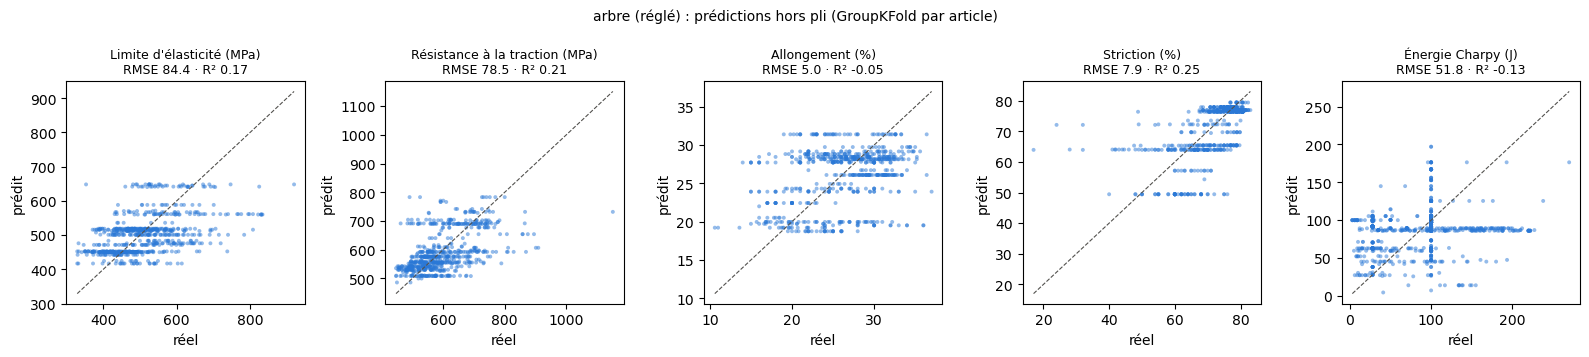

,,min réel,min prédit,max réel,max prédit
cible,modèle,,,,
Limite d'élasticité (MPa),arbre (réglé),329.0,417.0,920.0,648.2
Résistance à la traction (MPa),arbre (réglé),447.0,485.8,1151.0,783.0
Allongement (%),arbre (réglé),10.6,18.7,37.0,31.4
Striction (%),arbre (réglé),17.0,49.4,83.0,79.4
Énergie Charpy (J),arbre (réglé),3.0,4.5,270.0,197.0


In [10]:
figure_predit_reel("arbre (réglé)", "arbre_predit_reel.pdf")
# Les prédictions restent-elles dans la plage des valeurs observées ?
display(plage(["régression linéaire", "arbre (réglé)"]))

**Constat** :
- **Aucune prédiction impossible** : toutes les prédictions restent dans la plage des valeurs observées, alors que la régression linéaire prédisait jusqu'à −85 MPa de limite d'élasticité ou −185 J d'énergie Charpy.
- **L'arbre écrase les extrêmes** : il ne prédit jamais plus de 648 MPa de limite d'élasticité, alors que les valeurs réelles montent à 920 MPa. Une feuille fait la moyenne de plusieurs lignes, et les aciers très résistants sont trop rares pour former une feuille à eux seuls : ils sont donc sous-estimés.
- **Les paliers sont visibles** : il n'y a que quelques valeurs prédites, une par feuille. La moyenne de nombreux arbres (bagging, forêt, partie 6.2) donnera des prédictions plus continues.

### 6.1.5 Lecture de l'arbre

L'arbre final de la limite d'élasticité, entraîné sur toutes les lignes avec les hyperparamètres choisis par validation croisée. Si l'arbre est plus profond, seuls les 3 premiers niveaux sont affichés : ce sont les découpages qui réduisent le plus l'erreur. Chaque nœud indique la question posée, le nombre de lignes (`samples`) et la valeur moyenne de la cible (`value`).

Comme pour les coefficients de la régression, ces règles décrivent les données publiées, pas des effets causaux. Et vu la variance de l'arbre, un autre jeu d'articles pourrait donner d'autres questions.

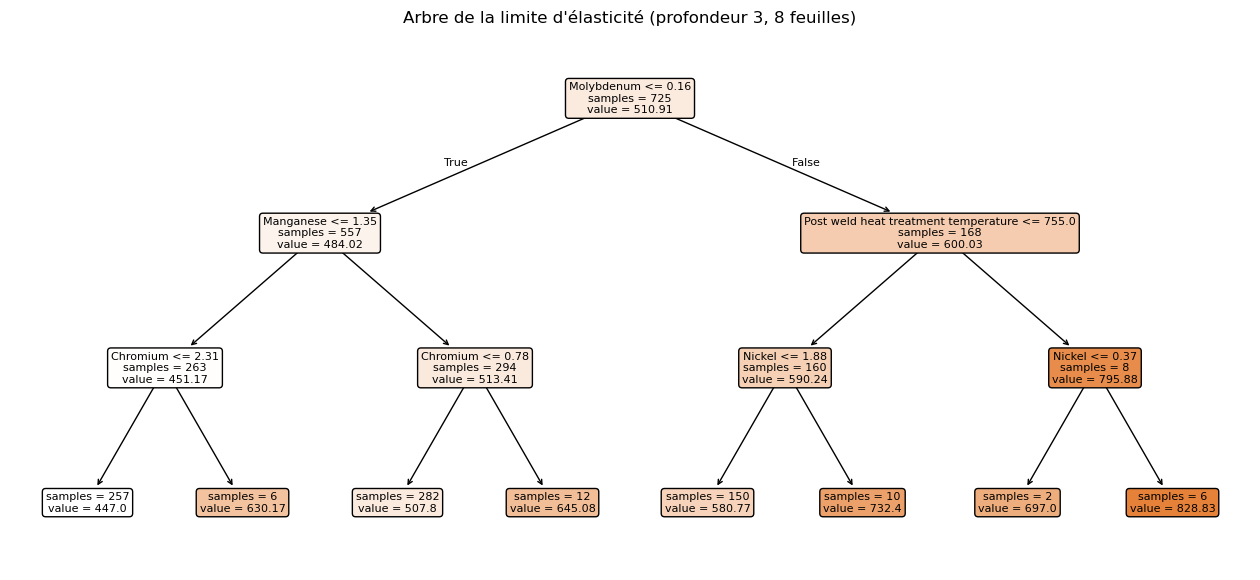

In [11]:
def nom_court(colonne):
    """'col03_Manganese_concentration' -> 'Manganese', 'missingindicator_col06_...' -> 'manquant : Nickel'."""
    manquant = colonne.startswith("missingindicator_")
    nom = re.sub(r"^(missingindicator_)?col\d+_", "", colonne)
    nom = nom.replace("_concentration", "").replace("_", " ")
    return ("manquant : " if manquant else "") + nom


final = finaux[("yield", "arbre (réglé)")]
t = final.named_steps["modele"]
noms = [nom_court(c) for c in final.named_steps["prep"].get_feature_names_out()]
fig, ax = plt.subplots(figsize=(16, 7))
plot_tree(t, max_depth=3, feature_names=noms, filled=True,
          impurity=False, rounded=True, precision=2, fontsize=8, ax=ax)
ax.set_title(f"Arbre de la limite d'élasticité (profondeur {t.get_depth()}, {t.get_n_leaves()} feuilles"
             + (", 3 premiers niveaux affichés)" if t.get_depth() > 3 else ")"))
fig.savefig(FIGURES / "arbre_yield.pdf", bbox_inches="tight")
plt.show()

**Constat** :
- **Le premier découpage porte sur le molybdène** (0,16 %), puis sur le manganèse, le chrome et le nickel : ce sont les éléments durcissants, déjà parmi les plus forts coefficients de la régression linéaire.
- **Une règle trompeuse** : chez les aciers au molybdène, un traitement thermique **au-dessus** de 755 °C donne une limite d'élasticité plus **élevée**. Cette règle ne repose que sur 8 lignes. Ce n'est pas un effet du traitement : seuls les aciers fortement alliés (type 9Cr-1Mo) sont revenus à une température aussi haute, et c'est leur composition qui les rend résistants. L'arbre reflète la façon dont les recettes sont regroupées dans les articles, pas un effet causal.
- **Pour le Charpy**, le premier découpage porte sur la température d'essai, comme attendu (passage du comportement fragile au ductile). Une feuille (41 lignes, toutes testées sous −80 °C) est composée à 90 % de lignes à exactement 28 J, celles où l'article donne la température de seuil plutôt qu'une énergie mesurée (section 2.3.5 du pré-traitement). La question des deux types de lignes Charpy se retrouve donc dans la structure de l'arbre.

## 6.2 Bagging et forêt aléatoire

### 6.2.1 Principe

L'arbre seul a une **forte variance** (partie 6.1.2) : sa structure change avec les données d'entraînement. Les méthodes d'ensemble réduisent cette variance en **moyennant de nombreux arbres**.

- **Bagging** (*bootstrap aggregating*) : chaque arbre est entraîné sur un échantillon bootstrap (tirage avec remise de n lignes parmi n), puis on fait la moyenne de leurs prédictions. Les arbres sont profonds (faible biais, forte variance), et la moyenne réduit la variance.
- **Forêt aléatoire** : un bagging où, à chaque découpage, l'arbre ne choisit que parmi une **fraction des variables** tirée au hasard (`max_features`). Les arbres se ressemblent moins, et la moyenne d'arbres moins corrélés réduit davantage la variance. C'est utile ici, où quelques variables très fortes (molybdène, manganèse, chrome) seraient sinon choisies en premier par tous les arbres.

**Mise en œuvre.** Les deux modèles utilisent `RandomForestRegressor` avec 300 arbres. Avec `max_features=1.0` (toutes les variables à chaque découpage), la forêt est exactement un bagging d'arbres. On règle par validation croisée imbriquée, comme pour l'arbre :
- **bagging** : `min_samples_leaf` seulement ;
- **forêt** : `min_samples_leaf` et `max_features`.

Le nombre d'arbres n'est pas un hyperparamètre à régler : au-delà de quelques centaines, ajouter des arbres ne change plus la prédiction, cela ne fait que coûter du temps de calcul.

**Pas d'erreur OOB.** Chaque arbre peut être évalué sur les lignes laissées de côté par son bootstrap (*out-of-bag*). Mais ce tirage mélange les articles : une ligne OOB a souvent des « jumelles » du même article dans le bootstrap. L'erreur OOB serait donc optimiste, comme le découpage aléatoire. On garde la validation croisée par article.

### 6.2.2 Résultats

Les deux modèles sont évalués avec le même protocole, puis comparés aux modèles précédents.

In [12]:
N_ARBRES = 300
GRILLE_BAGGING = {"modele__max_features": [1.0],
                  "modele__min_samples_leaf": [1, 3, 5, 10, 20]}
GRILLE_FORET = {"modele__max_features": [0.2, 0.33, 0.5, 0.7],
                "modele__min_samples_leaf": [1, 3, 5, 10, 20]}


def foret(X, grille):
    """Forêt aléatoire (bagging si max_features=1.0), préparation sans standardisation."""
    estimateur = RandomForestRegressor(n_estimators=N_ARBRES, random_state=GRAINE)
    return regle(pipeline(X, estimateur, standardiser=False), grille)


def bagging(X):
    return foret(X, GRILLE_BAGGING)


def foret_aleatoire(X):
    return foret(X, GRILLE_FORET)


ajouter("bagging (réglé)", bagging)
ajouter("forêt aléatoire (réglée)", foret_aleatoire)
for mesure in ["R²", "RMSE"]:
    print(f"{mesure} en validation croisée par article")
    display(comparer(mesure))

R² en validation croisée par article


,référence (moyenne),arbre (réglé),bagging (réglé),forêt aléatoire (réglée)
Limite d'élasticité (MPa),-0.02,0.17,0.35,0.44
Résistance à la traction (MPa),-0.05,0.21,0.39,0.44
Allongement (%),-0.03,-0.05,0.24,0.29
Striction (%),-0.13,0.25,0.43,0.47
Énergie Charpy (J),-0.04,-0.13,0.15,0.20


RMSE en validation croisée par article


,référence (moyenne),arbre (réglé),bagging (réglé),forêt aléatoire (réglée)
Limite d'élasticité (MPa),93.24,84.41,74.70,69.14
Résistance à la traction (MPa),90.78,78.51,69.00,66.44
Allongement (%),4.98,5.03,4.28,4.13
Striction (%),9.62,7.85,6.86,6.62
Énergie Charpy (J),49.73,51.81,44.97,43.59


**Constat** :
- **Les deux méthodes d'ensemble battent nettement l'arbre seul, et la moyenne sur les 5 cibles.** La forêt aléatoire est la meilleure partout, avec des R² de 0,20 (Charpy) à 0,47 (striction) en validation par article.
- **Gain par rapport à la moyenne** : la RMSE de la forêt baisse de 26 % pour la limite d'élasticité (69 MPa au lieu de 93), de 27 % pour la résistance à la traction, de 31 % pour la striction, de 17 % pour l'allongement et de 12 % pour le Charpy.
- **De l'arbre au bagging**, le R² gagne de 0,18 à 0,29 : moyenner des arbres réduit fortement la variance. **Du bagging à la forêt**, il gagne encore de 0,04 à 0,09 : tirer les variables au hasard décorrèle les arbres.
- **L'allongement et le Charpy**, où l'arbre seul ne faisait pas mieux que la moyenne, deviennent prévisibles en partie (R² 0,29 et 0,20). Ce sont toujours les deux cibles les plus difficiles.

### 6.2.3 Hyperparamètres choisis

Comme pour l'arbre (partie 6.1.2), les hyperparamètres retenus dans chacun des 5 plis externes.

In [13]:
for nom in ["bagging (réglé)", "forêt aléatoire (réglée)"]:
    print(nom)
    display(hyperparametres(nom))

bagging (réglé)


,Limite d'élasticité (MPa),Résistance à la traction (MPa),Allongement (%),Striction (%),Énergie Charpy (J)
pli 1,"max_features=1.0, min_samples_leaf=1","max_features=1.0, min_samples_leaf=3","max_features=1.0, min_samples_leaf=20","max_features=1.0, min_samples_leaf=1","max_features=1.0, min_samples_leaf=10"
pli 2,"max_features=1.0, min_samples_leaf=20","max_features=1.0, min_samples_leaf=3","max_features=1.0, min_samples_leaf=10","max_features=1.0, min_samples_leaf=20","max_features=1.0, min_samples_leaf=1"
pli 3,"max_features=1.0, min_samples_leaf=1","max_features=1.0, min_samples_leaf=3","max_features=1.0, min_samples_leaf=1","max_features=1.0, min_samples_leaf=1","max_features=1.0, min_samples_leaf=20"
pli 4,"max_features=1.0, min_samples_leaf=20","max_features=1.0, min_samples_leaf=1","max_features=1.0, min_samples_leaf=1","max_features=1.0, min_samples_leaf=20","max_features=1.0, min_samples_leaf=1"
pli 5,"max_features=1.0, min_samples_leaf=1","max_features=1.0, min_samples_leaf=1","max_features=1.0, min_samples_leaf=1","max_features=1.0, min_samples_leaf=20","max_features=1.0, min_samples_leaf=3"


forêt aléatoire (réglée)


,Limite d'élasticité (MPa),Résistance à la traction (MPa),Allongement (%),Striction (%),Énergie Charpy (J)
pli 1,"max_features=0.5, min_samples_leaf=1","max_features=0.33, min_samples_leaf=1","max_features=0.2, min_samples_leaf=1","max_features=0.5, min_samples_leaf=1","max_features=0.7, min_samples_leaf=10"
pli 2,"max_features=0.33, min_samples_leaf=1","max_features=0.7, min_samples_leaf=1","max_features=0.33, min_samples_leaf=3","max_features=0.2, min_samples_leaf=20","max_features=0.33, min_samples_leaf=1"
pli 3,"max_features=0.33, min_samples_leaf=1","max_features=0.5, min_samples_leaf=1","max_features=0.7, min_samples_leaf=1","max_features=0.33, min_samples_leaf=20","max_features=0.5, min_samples_leaf=1"
pli 4,"max_features=0.33, min_samples_leaf=3","max_features=0.5, min_samples_leaf=1","max_features=0.2, min_samples_leaf=3","max_features=0.2, min_samples_leaf=20","max_features=0.5, min_samples_leaf=1"
pli 5,"max_features=0.5, min_samples_leaf=1","max_features=0.5, min_samples_leaf=1","max_features=0.33, min_samples_leaf=1","max_features=0.2, min_samples_leaf=10","max_features=0.2, min_samples_leaf=1"


**Constat** :
- **Forêt** : `min_samples_leaf` vaut presque toujours 1 ou 3, c'est-à-dire des arbres profonds, comme le prévoit la théorie : la moyenne se charge de la variance, chaque arbre peut donc avoir un biais faible. Seule la striction préfère des feuilles plus grandes (10 à 20 lignes), ainsi que le Charpy dans un pli.
- **`max_features`** est le plus souvent de 20 à 50 % des variables : la forêt a bien besoin du tirage aléatoire des variables. Le bagging (100 %) n'est jamais aussi bon.
- **Bagging** : le réglage hésite davantage d'un pli à l'autre (feuilles de 1 à 20 lignes), mais un arbre moyen sur 300 est bien moins sensible à ce réglage qu'un arbre seul.

### 6.2.4 Biais ou variance ?

Le même diagnostic qu'en partie 6.1.3, pour les trois modèles à base d'arbres.

In [14]:
display(diagnostic(["arbre (réglé)", "bagging (réglé)", "forêt aléatoire (réglée)"]))

R² données apprises  \
cible                          modèle                                          
Limite d'élasticité (MPa)      arbre (réglé)                            0.52   
                               bagging (réglé)                          0.92   
                               forêt aléatoire (réglée)                 0.97   
Résistance à la traction (MPa) arbre (réglé)                            0.61   
                               bagging (réglé)                          0.98   
                               forêt aléatoire (réglée)                 0.93   
Allongement (%)                arbre (réglé)                            0.67   
                               bagging (réglé)                          0.96   
                               forêt aléatoire (réglée)                 0.96   
Striction (%)                  arbre (réglé)                            0.61   
                               bagging (réglé)                          0.88   
                               forêt aléatoire (réglée)                 0.96   
Énergie Charpy (J)             arbre (réglé)                            0.61   
                               bagging (réglé)                          0.98   
                               forêt aléatoire (réglée)                 0.97   

                                                         R² découpage aléatoire  \
cible                          modèle                                             
Limite d'élasticité (MPa)      arbre (réglé)                               0.45   
                               bagging (réglé)                             0.74   
                               forêt aléatoire (réglée)                    0.78   
Résistance à la traction (MPa) arbre (réglé)                               0.53   
                               bagging (réglé)                             0.84   
                               forêt aléatoire (réglée)                    0.80   
Allongement (%)                arbre (réglé)                               0.51   
                               bagging (réglé)                             0.71   
                               forêt aléatoire (réglée)                    0.71   
Striction (%)                  arbre (réglé)                               0.51   
                               bagging (réglé)                             0.70   
                               forêt aléatoire (réglée)                    0.70   
Énergie Charpy (J)             arbre (réglé)                               0.47   
                               bagging (réglé)                             0.80   
                               forêt aléatoire (réglée)                    0.77   

                                                         R² découpage par article  
cible                          modèle                                              
Limite d'élasticité (MPa)      arbre (réglé)                                 0.17  
                               bagging (réglé)                               0.35  
                               forêt aléatoire (réglée)                      0.44  
Résistance à la traction (MPa) arbre (réglé)                                 0.21  
                               bagging (réglé)                               0.39  
                               forêt aléatoire (réglée)                      0.44  
Allongement (%)                arbre (réglé)                                -0.05  
                               bagging (réglé)                               0.24  
                               forêt aléatoire (réglée)                      0.29  
Striction (%)                  arbre (réglé)                                 0.25  
                               bagging (réglé)                               0.43  
                               forêt aléatoire (réglée)                      0.47  
Énergie Charpy (J)             arbre (réglé)                                -0.13  
                        

**Constat** :
- **Biais** : le R² sur les données apprises passe de 0,52-0,71 (arbre) à 0,88-0,98 (bagging, forêt). Les arbres profonds décrivent presque parfaitement les données vues : le biais a disparu.
- **Variance au sens classique** : l'écart entre données apprises et découpage aléatoire est de 0,13 à 0,26. Il est normal qu'il soit grand, puisque des arbres profonds apprennent aussi le bruit des données vues. Mais en découpage aléatoire, le R² monte à 0,70-0,84 contre 0,45-0,53 pour l'arbre seul : la moyenne compense bien la variance de chaque arbre.
- **Changement de domaine** : l'écart entre découpage aléatoire et découpage par article reste **le plus grand** (0,23 à 0,57 pour la forêt), surtout pour le Charpy (0,77 contre 0,20). Les méthodes d'ensemble ont amélioré les deux découpages, sans réduire cet écart : prédire un article inconnu reste la difficulté principale.

### 6.2.5 Prédit contre réel

Les prédictions hors pli de la forêt aléatoire, et la plage des valeurs prédites par chaque modèle à base d'arbres.

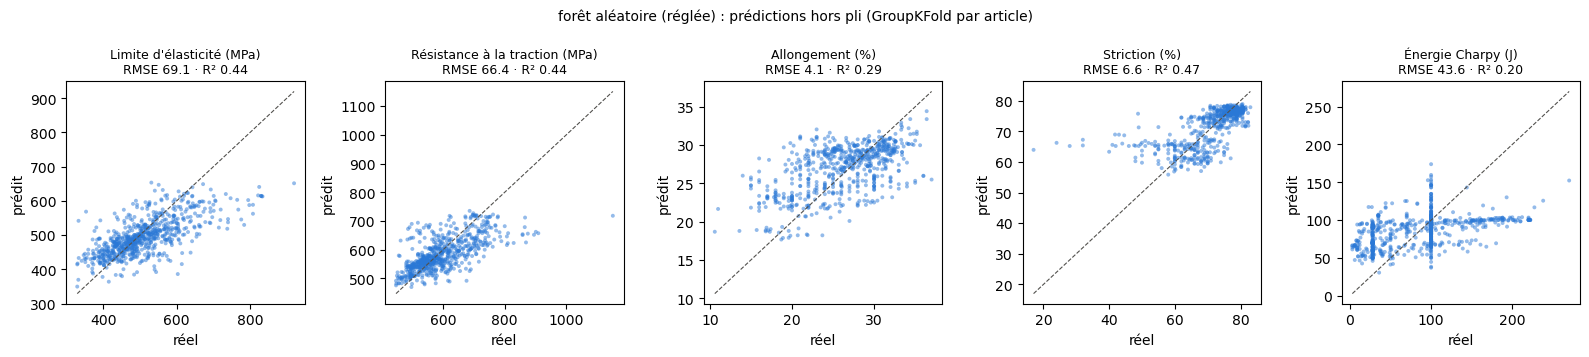

min réel  min prédit  \
cible                          modèle                                           
Limite d'élasticité (MPa)      arbre (réglé)                329.0       417.0   
                               bagging (réglé)              329.0       354.1   
                               forêt aléatoire (réglée)     329.0       349.5   
Résistance à la traction (MPa) arbre (réglé)                447.0       485.8   
                               bagging (réglé)              447.0       471.8   
                               forêt aléatoire (réglée)     447.0       469.9   
Allongement (%)                arbre (réglé)                 10.6        18.7   
                               bagging (réglé)               10.6        18.5   
                               forêt aléatoire (réglée)      10.6        17.7   
Striction (%)                  arbre (réglé)                 17.0        49.4   
                               bagging (réglé)               17.0        53.3   
                               forêt aléatoire (réglée)      17.0        55.8   
Énergie Charpy (J)             arbre (réglé)                  3.0         4.5   
                               bagging (réglé)                3.0        20.4   
                               forêt aléatoire (réglée)       3.0        30.7   

                                                         max réel  max prédit  
cible                          modèle                                          
Limite d'élasticité (MPa)      arbre (réglé)                920.0       648.2  
                               bagging (réglé)              920.0       662.4  
                               forêt aléatoire (réglée)     920.0       653.5  
Résistance à la traction (MPa) arbre (réglé)               1151.0       783.0  
                               bagging (réglé)             1151.0       748.1  
                               forêt aléatoire (réglée)    1151.0       735.1  
Allongement (%)                arbre (réglé)                 37.0        31.4  
                               bagging (réglé)               37.0        34.6  
                               forêt aléatoire (réglée)      37.0        34.4  
Striction (%)                  arbre (réglé)                 83.0        79.4  
                               bagging (réglé)               83.0        79.7  
                               forêt aléatoire (réglée)      83.0        78.9  
Énergie Charpy (J)             arbre (réglé)                270.0       197.0  
                               bagging (réglé)              270.0       174.1  
                               forêt aléatoire (réglée)     270.0       174.0

In [15]:
figure_predit_reel("forêt aléatoire (réglée)", "foret_predit_reel.pdf")
display(plage(["arbre (réglé)", "bagging (réglé)", "forêt aléatoire (réglée)"]))

**Constat** :
- **Aucune prédiction impossible**, comme pour l'arbre : une forêt fait la moyenne de valeurs observées.
- **Les extrêmes sont encore plus écrasés** : la moyenne de 300 arbres tire les prédictions vers le centre. La forêt ne prédit jamais plus de 654 MPa de limite d'élasticité (920 MPa en réalité). Pour le Charpy, elle ne descend jamais sous 31 J alors que des soudures fragiles ont 3 J. Pour cet usage, c'est le défaut le plus gênant : les soudures fragiles sont celles qu'on cherche justement à éviter.
- **Les paliers de l'arbre ont disparu** : les prédictions sont continues.

# 7. Apprentissage semi-supervisé — *à attribuer*

*Section réservée.* Méthodes exploitant les lignes où la cible n'est pas mesurée (auto-apprentissage, co-régression COREG).

In [16]:
# Apprentissage semi-supervisé : voir la partie 8.

# 8. Ajouter un modèle

1. **Écrire une fonction** qui reçoit X et renvoie le modèle non entraîné :
   - `pipeline(X, estimateur)` ajoute la préparation commune (avec standardisation ; `standardiser=False` pour les modèles à base d'arbres) ;
   - si le modèle a des hyperparamètres, l'envelopper dans `regle(modèle, grille)`, avec des noms de paramètres préfixés par `modele__`.
2. **Appeler `ajouter("nom", fonction)`** : le modèle est évalué sur les 5 cibles, avec les mêmes plis, et ses résultats rejoignent les tableaux.
3. **Analyser** avec les outils de la partie 1 (`tableau_complet`, `hyperparametres`, `diagnostic`, `figure_predit_reel`, `plage`), et écrire les constats.
4. **Écrire dans la section de sa famille** (parties 4 à 7) : la comparaison finale (partie 9) reprend automatiquement tous les modèles ajoutés.

Gabarit (`MonEstimateur` et `un_parametre` sont à remplacer) :

```python
GRILLE = {"modele__un_parametre": [0.1, 1, 10]}


def mon_modele(X):
    return regle(pipeline(X, MonEstimateur()), GRILLE)


ajouter("mon modèle (réglé)", mon_modele)
display(tableau_complet(["référence (moyenne)", "mon modèle (réglé)"]))
display(hyperparametres("mon modèle (réglé)"))
```

Sans hyperparamètre à régler, la fonction renvoie directement `pipeline(X, MonEstimateur())`.

# 9. Comparaison de tous les modèles

Les tableaux reprennent automatiquement tous les modèles ajoutés dans les parties précédentes.

In [17]:
for mesure in ["R²", "RMSE"]:
    print(f"{mesure} en validation croisée par article")
    display(comparer(mesure))
r2 = comparer("R²")
display(pd.DataFrame({"meilleur modèle": r2.idxmax(axis=1), "R²": r2.max(axis=1)}))

R² en validation croisée par article


,référence (moyenne),arbre (réglé),bagging (réglé),forêt aléatoire (réglée)
Limite d'élasticité (MPa),-0.02,0.17,0.35,0.44
Résistance à la traction (MPa),-0.05,0.21,0.39,0.44
Allongement (%),-0.03,-0.05,0.24,0.29
Striction (%),-0.13,0.25,0.43,0.47
Énergie Charpy (J),-0.04,-0.13,0.15,0.20


RMSE en validation croisée par article


,référence (moyenne),arbre (réglé),bagging (réglé),forêt aléatoire (réglée)
Limite d'élasticité (MPa),93.24,84.41,74.70,69.14
Résistance à la traction (MPa),90.78,78.51,69.00,66.44
Allongement (%),4.98,5.03,4.28,4.13
Striction (%),9.62,7.85,6.86,6.62
Énergie Charpy (J),49.73,51.81,44.97,43.59


,meilleur modèle,R²
Limite d'élasticité (MPa),forêt aléatoire (réglée),0.44
Résistance à la traction (MPa),forêt aléatoire (réglée),0.44
Allongement (%),forêt aléatoire (réglée),0.29
Striction (%),forêt aléatoire (réglée),0.47
Énergie Charpy (J),forêt aléatoire (réglée),0.20


**Bilan des arbres et méthodes d'ensemble** (partie 6, *Salomé*) :

- **Résultat** : la forêt aléatoire est le meilleur modèle testé jusqu'ici, sur les 5 cibles. En validation par article, son R² va de 0,20 à 0,47 et sa RMSE est de 12 à 31 % plus basse que celle de la moyenne.

- **Chaque étape améliore la précédente** : l'arbre seul supprime l'extrapolation mais garde une forte variance, et le bagging puis la forêt réduisent cette variance.
- **Ce qui reste difficile** :
  - **le changement de domaine entre articles** : c'est encore le plus grand écart du diagnostic ;
  - **les extrêmes** : les aciers très résistants et les soudures très fragiles sont ramenés vers le centre ;
  - **le Charpy** : c'est la cible la moins bien prédite.

**Suite possible** :
1. **Extra-Trees** : une forêt dont les seuils de découpage sont aussi tirés au hasard. On les ajoute avec `ajouter` (partie 8).
2. **Importance des variables par permutation**, calculée sur les plis par article, à comparer aux coefficients de la régression linéaire et à l'arbre de la partie 6.1.5.
3. **Charpy** : refaire l'évaluation avec les 404 énergies réellement mesurées seulement, pour trancher la question des lignes fixées à 100 J et 28 J.